# Stage 1 — Transaction Data Validation & Behavioural Analysis

### Objective
Analyse the historical transaction behaviour of a single customer
using six months of structured banking transaction data before
applying forecasting models.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import shapiro
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving customer_transactions_6_months_2026_with_share_market_flag.csv to customer_transactions_6_months_2026_with_share_market_flag (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv(
    "customer_transactions_6_months_2026_with_share_market_flag.csv"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (181, 5)


,date,credit,debit,balance,share_market_flag
0,2026-01-01,50000,401,69599,0
1,2026-01-02,0,236,69363,0
2,2026-01-03,0,796,68567,0
3,2026-01-04,0,653,67914,0
4,2026-01-05,0,12480,55434,1


In [ ]:
# ============================================
# SHARE MARKET FLAG VALIDATION
# ============================================

print("Share Market Flag Values")
print("========================")
print(df["share_market_flag"].value_counts())

# Check that only 0 and 1 are present
invalid_values = df[
    ~df["share_market_flag"].isin([0, 1])
]

print("\nInvalid flag values:")
display(invalid_values)

# Check that flagged transactions are debit transactions
invalid_flagged = df[
    (df["share_market_flag"] == 1) &
    (df["debit"] <= 0)
]

print("\nFlagged transactions that are NOT debit transactions:")
display(invalid_flagged)

Share Market Flag Values
share_market_flag
0    175
1      6
Name: count, dtype: int64

Invalid flag values:


,date,credit,debit,balance,share_market_flag



Flagged transactions that are NOT debit transactions:


,date,credit,debit,balance,share_market_flag


## Phase 2 — Data Loading & Initial Validation

In [ ]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

df.info()

Number of rows: 181
Number of columns: 5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               181 non-null    object
 1   credit             181 non-null    int64 
 2   debit              181 non-null    int64 
 3   balance            181 non-null    int64 
 4   share_market_flag  181 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.2+ KB


In [ ]:
df.describe()

,credit,debit,balance,share_market_flag
count,181.000000,181.000000,181.000000,181.000000
mean,1878.453039,1393.613260,83163.497238,0.033149
std,9207.734058,2480.692989,26754.540585,0.179523
min,0.000000,151.000000,33016.000000,0.000000
25%,0.000000,484.000000,61267.000000,0.000000
50%,0.000000,602.000000,83564.000000,0.000000
75%,0.000000,796.000000,101821.000000,0.000000
max,53000.000000,12922.000000,140442.000000,1.000000


In [ ]:
df.isnull().sum()

,0
date,0
credit,0
debit,0
balance,0
share_market_flag,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

df.head()

,date,credit,debit,balance,share_market_flag
0,2026-01-01,50000,401,69599,0
1,2026-01-02,0,236,69363,0
2,2026-01-03,0,796,68567,0
3,2026-01-04,0,653,67914,0
4,2026-01-05,0,12480,55434,1


In [ ]:
df["net_flow"] = df["credit"] - df["debit"]

df.head()

,date,credit,debit,balance,share_market_flag,net_flow
0,2026-01-01,50000,401,69599,0,49599
1,2026-01-02,0,236,69363,0,-236
2,2026-01-03,0,796,68567,0,-796
3,2026-01-04,0,653,67914,0,-653
4,2026-01-05,0,12480,55434,1,-12480


## Monthly Aggregation

Daily transactions are aggregated into monthly credit, debit and net flow
to create the time-series representation used for the initial behavioural analysis.

In [ ]:
# ============================================
# MONTHLY AGGREGATION
# ============================================

# Make sure date is in datetime format
df["date"] = pd.to_datetime(df["date"])

# Create month column
df["month"] = df["date"].dt.to_period("M")

# Aggregate monthly data
monthly = (
    df.groupby("month")
      .agg(
          total_credit=("credit", "sum"),
          total_debit=("debit", "sum"),
          closing_balance=("balance", "last")
      )
      .reset_index()
)

# Calculate total share-market-related debit
share_market_debit = (
    df[df["share_market_flag"] == 1]
    .groupby("month")["debit"]
    .sum()
    .rename("share_market_debit")
)

# Add share-market debit to monthly table
monthly = monthly.merge(
    share_market_debit,
    on="month",
    how="left"
)

# Months with no share-market debit get 0
monthly["share_market_debit"] = (
    monthly["share_market_debit"]
    .fillna(0)
)

# Calculate net flow
monthly["net_flow"] = (
    monthly["total_credit"] -
    monthly["total_debit"]
)

print("Monthly Transaction Summary")
print("===========================")

display(monthly)

Monthly Transaction Summary


,month,total_credit,total_debit,closing_balance,share_market_debit,net_flow
0,2026-01,55000,41984,33016,12480,13016
1,2026-02,54500,38286,49230,12415,16214
2,2026-03,57000,41967,64263,12729,15033
3,2026-04,56000,41930,78333,12638,14070
4,2026-05,58500,48966,87867,12820,9534
5,2026-06,59000,39111,107756,12922,19889


In [ ]:
# ============================================
# SHARE-MARKET BEHAVIOUR SUMMARY
# ============================================

monthly["share_market_ratio"] = (
    monthly["share_market_debit"] /
    monthly["total_debit"]
) * 100

print("Share-Market Behaviour")
print("======================")

display(
    monthly[
        [
            "month",
            "total_debit",
            "share_market_debit",
            "share_market_ratio"
        ]
    ]
)

Share-Market Behaviour


,month,total_debit,share_market_debit,share_market_ratio
0,2026-01,41984,12480,29.725610
1,2026-02,38286,12415,32.426997
2,2026-03,41967,12729,30.330974
3,2026-04,41930,12638,30.140711
4,2026-05,48966,12820,26.181432
5,2026-06,39111,12922,33.039298


## Phase 3 — Trend Analysis

In [ ]:
# Month index: 1 to 6
X = np.arange(1, len(monthly) + 1).reshape(-1, 1)

# Monthly credit values
y = monthly["total_credit"].values

In [ ]:
model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_

print("Slope:", slope)
print("Intercept:", intercept)

Slope: 885.7142857142857
Intercept: 53566.666666666664


In [ ]:
if slope > 0:
    trend = "UPWARD"
elif slope < 0:
    trend = "DOWNWARD"
else:
    trend = "FLAT"

print("Trend:", trend)

Trend: UPWARD


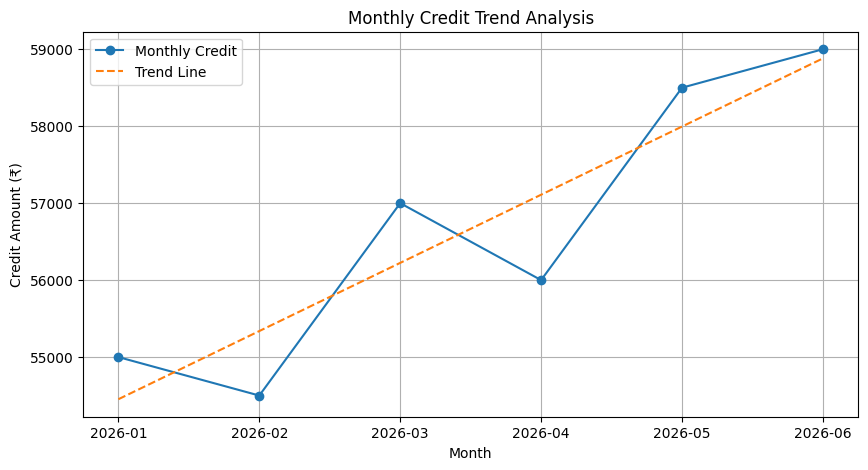

In [ ]:
predicted = model.predict(X)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly["month"].astype(str),
    y,
    marker="o",
    label="Monthly Credit"
)

plt.plot(
    monthly["month"].astype(str),
    predicted,
    linestyle="--",
    label="Trend Line"
)

plt.xlabel("Month")
plt.ylabel("Credit Amount (₹)")
plt.title("Monthly Credit Trend Analysis")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Calculate 3-month moving average of monthly credits
monthly["moving_average_3m"] = (
    monthly["total_credit"]
    .rolling(window=3)
    .mean()
)

monthly

,month,total_credit,total_debit,closing_balance,share_market_debit,net_flow,share_market_ratio,moving_average_3m
0,2026-01,55000,41984,33016,12480,13016,29.725610,NaN
1,2026-02,54500,38286,49230,12415,16214,32.426997,NaN
2,2026-03,57000,41967,64263,12729,15033,30.330974,55500.000000
3,2026-04,56000,41930,78333,12638,14070,30.140711,55833.333333
4,2026-05,58500,48966,87867,12820,9534,26.181432,57166.666667
5,2026-06,59000,39111,107756,12922,19889,33.039298,57833.333333


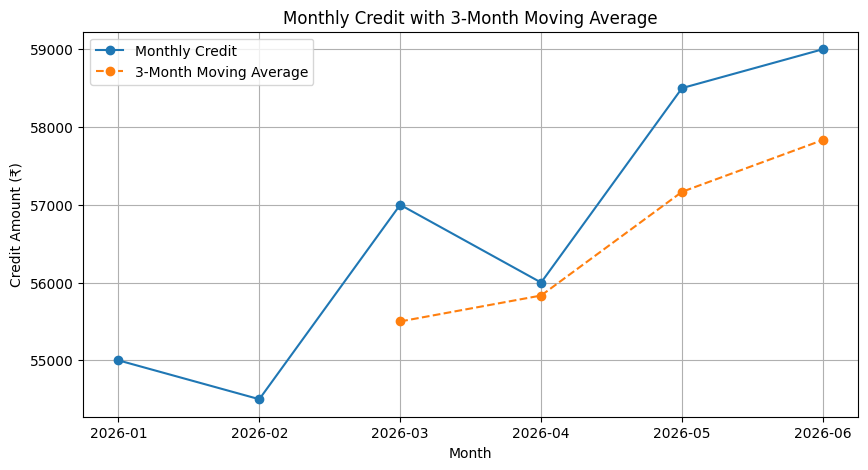

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly["month"].astype(str),
    monthly["total_credit"],
    marker="o",
    label="Monthly Credit"
)

plt.plot(
    monthly["month"].astype(str),
    monthly["moving_average_3m"],
    marker="o",
    linestyle="--",
    label="3-Month Moving Average"
)

plt.xlabel("Month")
plt.ylabel("Credit Amount (₹)")
plt.title("Monthly Credit with 3-Month Moving Average")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Calculate autocorrelation for monthly credits

credit_series = monthly["total_credit"]

lag_1 = credit_series.autocorr(lag=1)
lag_2 = credit_series.autocorr(lag=2)
lag_3 = credit_series.autocorr(lag=3)

print("Autocorrelation Results")
print("-----------------------")
print(f"Lag 1: {lag_1:.4f}")
print(f"Lag 2: {lag_2:.4f}")
print(f"Lag 3: {lag_3:.4f}")

Autocorrelation Results
-----------------------
Lag 1: 0.5512
Lag 2: 0.8598
Lag 3: 0.4703


In [ ]:
# Basic prototype interpretation

acf_values = {
    1: lag_1,
    2: lag_2,
    3: lag_3
}

strong_lags = [
    lag for lag, value in acf_values.items()
    if abs(value) > 0.7
]

if strong_lags:
    print(f"Strong autocorrelation detected at lag(s): {strong_lags}")
else:
    print("No strong autocorrelation detected at lags 1-3.")

Strong autocorrelation detected at lag(s): [2]


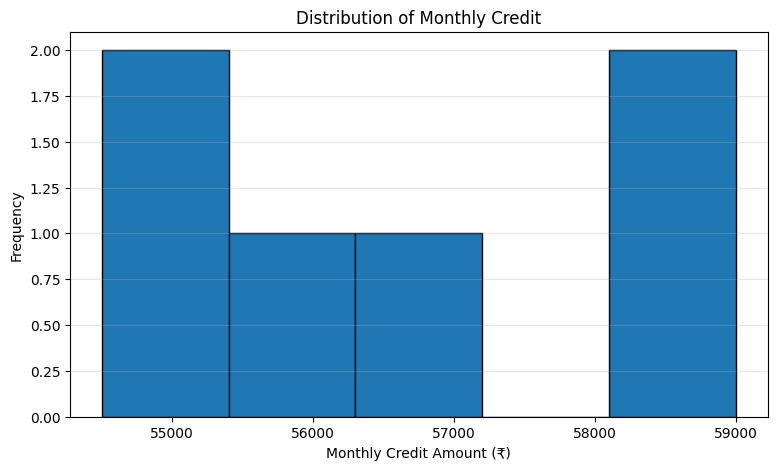

In [ ]:
# Monthly credit values
credit_values = monthly["total_credit"]

# Plot the distribution
plt.figure(figsize=(9, 5))

plt.hist(
    credit_values,
    bins=5,
    edgecolor="black"
)

plt.xlabel("Monthly Credit Amount (₹)")
plt.ylabel("Frequency")
plt.title("Distribution of Monthly Credit")

plt.grid(axis="y", alpha=0.3)
plt.show()

In [ ]:
from scipy.stats import shapiro

# Shapiro-Wilk normality test
statistic, p_value = shapiro(credit_values)

print("Shapiro-Wilk Test")
print("-----------------")
print(f"Test Statistic: {statistic:.4f}")
print(f"p-value: {p_value:.4f}")

Shapiro-Wilk Test
-----------------
Test Statistic: 0.9335
p-value: 0.6075


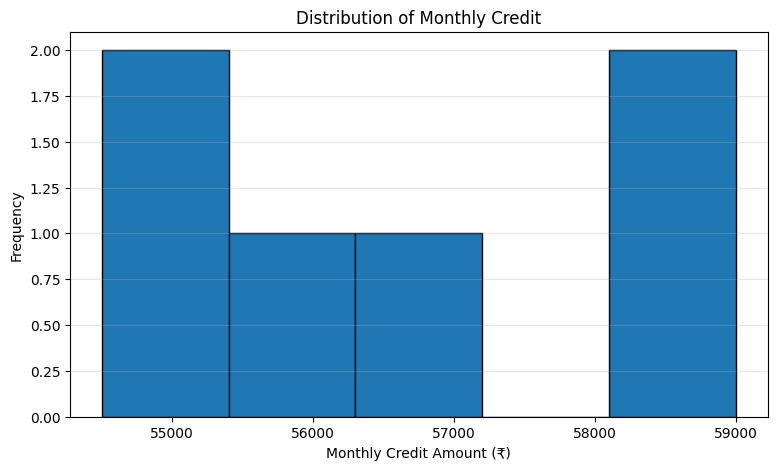

In [ ]:
credit_values = monthly["total_credit"]

plt.figure(figsize=(9, 5))

plt.hist(
    credit_values,
    bins=5,
    edgecolor="black"
)

plt.xlabel("Monthly Credit Amount (₹)")
plt.ylabel("Frequency")
plt.title("Distribution of Monthly Credit")

plt.grid(axis="y", alpha=0.3)
plt.show()

In [ ]:
from scipy.stats import shapiro

statistic, p_value = shapiro(credit_values)

print("Shapiro-Wilk Test")
print("-----------------")
print(f"Test Statistic: {statistic:.4f}")
print(f"p-value: {p_value:.4f}")


Shapiro-Wilk Test
-----------------
Test Statistic: 0.9335
p-value: 0.6075


In [ ]:
if p_value > 0.05:
    distribution = "Approximately Normal (Gaussian)"
    transformation = "None"
else:
    distribution = "Non-Normal"
    transformation = "To be investigated"

print("Distribution:", distribution)
print("Transformation:", transformation)

Distribution: Approximately Normal (Gaussian)
Transformation: None


In [ ]:
from statsmodels.tsa.stattools import adfuller

# Monthly credit time series
credit_series = monthly["total_credit"]

# Run Augmented Dickey-Fuller test
adf_result = adfuller(credit_series)

adf_statistic = adf_result[0]
p_value = adf_result[1]

print("Augmented Dickey-Fuller (ADF) Test")
print("----------------------------------")
print(f"ADF Statistic: {adf_statistic:.4f}")
print(f"p-value: {p_value:.4f}")

Augmented Dickey-Fuller (ADF) Test
----------------------------------
ADF Statistic: 0.4248
p-value: 0.9824


In [ ]:
if p_value < 0.05:
    stationarity = "STATIONARY"
    print("Stationarity: STATIONARY")
else:
    stationarity = "NON-STATIONARY"
    print("Stationarity: NON-STATIONARY")

Stationarity: NON-STATIONARY


In [ ]:
# First-order differencing
credit_diff = credit_series.diff().dropna()

print("Differenced Credit Series:")
print(credit_diff)

Differenced Credit Series:
1    -500.0
2    2500.0
3   -1000.0
4    2500.0
5     500.0
Name: total_credit, dtype: float64


In [ ]:
# ADF test after first-order differencing
adf_diff_result = adfuller(credit_diff)

adf_diff_statistic = adf_diff_result[0]
adf_diff_p_value = adf_diff_result[1]

print("ADF Test After First Differencing")
print("----------------------------------")
print(f"ADF Statistic: {adf_diff_statistic:.4f}")
print(f"p-value: {adf_diff_p_value:.4f}")

if adf_diff_p_value < 0.05:
    print("Stationarity: STATIONARY")
else:
    print("Stationarity: NON-STATIONARY")

ADF Test After First Differencing
----------------------------------
ADF Statistic: -7.7068
p-value: 0.0000
Stationarity: STATIONARY


In [ ]:
avg_monthly_credit = monthly["total_credit"].mean()
avg_monthly_debit = monthly["total_debit"].mean()
avg_monthly_net_flow = monthly["net_flow"].mean()

print("Average Monthly Credit   :", round(avg_monthly_credit, 2))
print("Average Monthly Debit    :", round(avg_monthly_debit, 2))
print("Average Monthly Net Flow :", round(avg_monthly_net_flow, 2))

Average Monthly Credit   : 56666.67
Average Monthly Debit    : 42040.67
Average Monthly Net Flow : 14626.0


In [ ]:
latest_moving_average = monthly["moving_average_3m"].iloc[-1]

print("Latest 3-Month Moving Average:", round(latest_moving_average, 2))

Latest 3-Month Moving Average: 57833.33


In [ ]:
behavioral_summary = {
    "customer_type": "Savings",

    "avg_monthly_credit": round(avg_monthly_credit, 2),
    "avg_monthly_debit": round(avg_monthly_debit, 2),
    "avg_monthly_net_flow": round(avg_monthly_net_flow, 2),

    "trend": trend,
    "trend_slope": round(slope, 2),

    "moving_avg_latest": round(latest_moving_average, 2),

    "autocorrelation_lag_1": round(lag_1, 4),
    "autocorrelation_lag_2": round(lag_2, 4),
    "autocorrelation_lag_3": round(lag_3, 4),

    "seasonality": "POSSIBLE PATTERN AT LAG 2",

    "distribution": distribution,
    "shapiro_p_value": round(p_value, 4),
    "transformation": transformation,

    "initial_stationarity": "NON-STATIONARY",
    "initial_adf_p_value": round(adf_diff_result[1], 4),
    "differencing": "FIRST-ORDER",
    "final_stationarity": "STATIONARY"
}

behavioral_summary

{'customer_type': 'Savings',
 'avg_monthly_credit': np.float64(56666.67),
 'avg_monthly_debit': np.float64(42040.67),
 'avg_monthly_net_flow': np.float64(14626.0),
 'trend': 'UPWARD',
 'trend_slope': np.float64(885.71),
 'moving_avg_latest': np.float64(57833.33),
 'autocorrelation_lag_1': np.float64(0.5512),
 'autocorrelation_lag_2': np.float64(0.8598),
 'autocorrelation_lag_3': np.float64(0.4703),
 'seasonality': 'POSSIBLE PATTERN AT LAG 2',
 'distribution': 'Approximately Normal (Gaussian)',
 'shapiro_p_value': np.float64(0.9824),
 'transformation': 'None',
 'initial_stationarity': 'NON-STATIONARY',
 'initial_adf_p_value': np.float64(0.0),
 'differencing': 'FIRST-ORDER',
 'final_stationarity': 'STATIONARY'}

In [ ]:
print("==============================================")
print("       CUSTOMER BEHAVIOURAL SUMMARY")
print("==============================================")

print(f"Customer Type           : {behavioral_summary['customer_type']}")
print()

print("FINANCIAL BEHAVIOUR")
print("----------------------------------------------")
print(f"Average Monthly Credit  : ₹{behavioral_summary['avg_monthly_credit']:,.2f}")
print(f"Average Monthly Debit   : ₹{behavioral_summary['avg_monthly_debit']:,.2f}")
print(f"Average Monthly Net Flow: ₹{behavioral_summary['avg_monthly_net_flow']:,.2f}")
print()

print("TREND")
print("----------------------------------------------")
print(f"Trend Direction         : {behavioral_summary['trend']}")
print(f"Regression Slope        : ₹{behavioral_summary['trend_slope']:,.2f}/month")
print()

print("MOVING AVERAGE")
print("----------------------------------------------")
print(f"Latest 3-Month MA       : ₹{behavioral_summary['moving_avg_latest']:,.2f}")
print()

print("AUTOCORRELATION")
print("----------------------------------------------")
print(f"Lag 1                   : {behavioral_summary['autocorrelation_lag_1']}")
print(f"Lag 2                   : {behavioral_summary['autocorrelation_lag_2']}")
print(f"Lag 3                   : {behavioral_summary['autocorrelation_lag_3']}")
print(f"Seasonality             : {behavioral_summary['seasonality']}")
print()

print("DISTRIBUTION")
print("----------------------------------------------")
print(f"Distribution            : {behavioral_summary['distribution']}")
print(f"Shapiro-Wilk p-value    : {behavioral_summary['shapiro_p_value']}")
print(f"Transformation          : {behavioral_summary['transformation']}")
print()

print("STATIONARITY")
print("----------------------------------------------")
print(f"Initial Status          : {behavioral_summary['initial_stationarity']}")
print(f"Initial ADF p-value     : {behavioral_summary['initial_adf_p_value']}")
print(f"Differencing            : {behavioral_summary['differencing']}")
print(f"Final Status            : {behavioral_summary['final_stationarity']}")

print("==============================================")

       CUSTOMER BEHAVIOURAL SUMMARY
Customer Type           : Savings

FINANCIAL BEHAVIOUR
----------------------------------------------
Average Monthly Credit  : ₹56,666.67
Average Monthly Debit   : ₹42,040.67
Average Monthly Net Flow: ₹14,626.00

TREND
----------------------------------------------
Trend Direction         : UPWARD
Regression Slope        : ₹885.71/month

MOVING AVERAGE
----------------------------------------------
Latest 3-Month MA       : ₹57,833.33

AUTOCORRELATION
----------------------------------------------
Lag 1                   : 0.5512
Lag 2                   : 0.8598
Lag 3                   : 0.4703
Seasonality             : POSSIBLE PATTERN AT LAG 2

DISTRIBUTION
----------------------------------------------
Distribution            : Approximately Normal (Gaussian)
Shapiro-Wilk p-value    : 0.9824
Transformation          : None

STATIONARITY
----------------------------------------------
Initial Status          : NON-STATIONARY
Initial ADF p-value     

# Stage 2 — Traditional Forecasting

## Objective

Forecast the customer's future monthly credit behaviour using
traditional time-series forecasting models and compare their
performance.

## Phase 1 — ARIMA Forecasting

The monthly credit series obtained from Stage 1 is used as the
forecasting target. The original series is retained so that
predictions can be interpreted in the original rupee scale.

In [ ]:
# Monthly credit series from Stage 1
monthly_credits = monthly["total_credit"].copy()

print("Monthly Credit Values:")
print(monthly_credits)

Monthly Credit Values:
0    55000
1    54500
2    57000
3    56000
4    58500
5    59000
Name: total_credit, dtype: int64


In [ ]:
# Train = first 5 months
train = monthly_credits.iloc[:5]

# Test = June
test = monthly_credits.iloc[5:]

print("Training Data:")
print(train)

print("\nTest Data:")
print(test)

Training Data:
0    55000
1    54500
2    57000
3    56000
4    58500
Name: total_credit, dtype: int64

Test Data:
5    59000
Name: total_credit, dtype: int64


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA(1,1,1)
arima_model = ARIMA(
    train,
    order=(1, 1, 1)
)

arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:           total_credit   No. Observations:                    5
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -32.975
Date:                Wed, 19 Aug 2026   AIC                             71.949
Time:                        16:34:56   BIC                             70.108
Sample:                             0   HQIC                            67.909
                                  - 5                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9989      0.193     -5.171      0.000      -1.378      -0.620
ma.L1          0.9880      1.076      0.918      0.359      -1.122       3.098
sigma2      8.317e+05   3.89e-07   2.14e+12      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:3160: UserWarning: Early subset of data for variable 0 has too few non-missing observations to calculate test statistic.
  test_statistic, p_value = breakvar_heteroskedasticity_test(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:3160: UserWarning: Later subset of data for variable 0 has too few non-missing observations to calculate test statistic.
  test_statistic, p_value = breakvar_heteroskedasticity_test(


In [ ]:
# Forecast the next month
arima_forecast = arima_result.forecast(steps=1)

predicted_june = arima_forecast.iloc[0]

print(f"ARIMA predicted June credit: ₹{predicted_june:,.2f}")
print(f"Actual June credit:          ₹{test.iloc[0]:,.2f}")

ARIMA predicted June credit: ₹56,900.91
Actual June credit:          ₹59,000.00


In [ ]:
actual_june = test.iloc[0]

mae = abs(actual_june - predicted_june)

print(f"MAE: ₹{mae:,.2f}")

MAE: ₹2,099.09


In [ ]:
mape = (mae / abs(actual_june)) * 100

print(f"MAPE: {mape:.2f}%")

MAPE: 3.56%


## ARIMA(1,1,1) — Results

The ARIMA(1,1,1) model was trained using the first five
monthly credit observations and used to forecast the sixth
month.

Training observations: 5
Testing observations: 1

Forecast:
- Predicted June Credit: ₹56,900.91
- Actual June Credit: ₹59,000.00
- MAE: ₹2,099.09
- MAPE: 3.56%

The model produced a forecast, but the result is preliminary
because the available dataset contains only six monthly
observations. The ARIMA fitting process also produced
convergence and small-sample warnings.

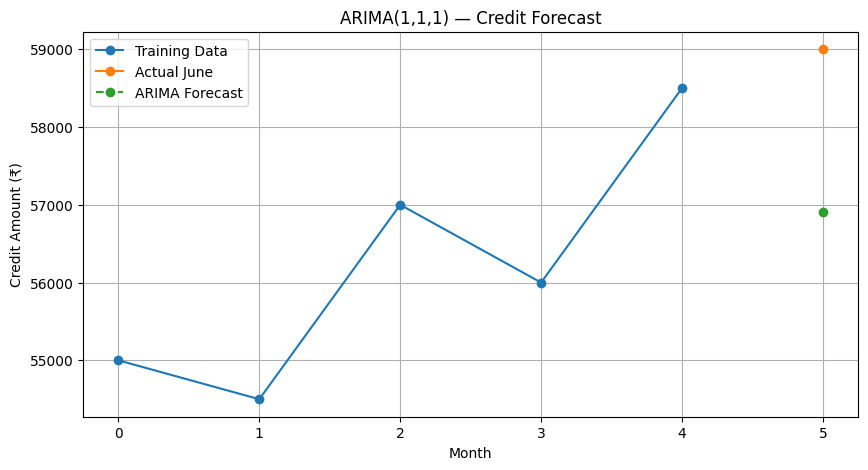

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Actual training data
plt.plot(
    train.index,
    train.values,
    marker="o",
    label="Training Data"
)

# Actual test value
plt.plot(
    test.index,
    test.values,
    marker="o",
    label="Actual June"
)

# ARIMA prediction
plt.plot(
    test.index,
    [predicted_june],
    marker="o",
    linestyle="--",
    label="ARIMA Forecast"
)

plt.xlabel("Month")
plt.ylabel("Credit Amount (₹)")
plt.title("ARIMA(1,1,1) — Credit Forecast")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
arima_results = {
    "model": "ARIMA(1,1,1)",
    "forecast": predicted_june,
    "actual": actual_june,
    "MAE": mae,
    "MAPE": mape
}

arima_results

{'model': 'ARIMA(1,1,1)',
 'forecast': np.float64(56900.90941779743),
 'actual': np.int64(59000),
 'MAE': np.float64(2099.090582202567),
 'MAPE': np.float64(3.5577806478009606)}

## Phase 2 — SARIMA Forecasting

SARIMA extends ARIMA by adding a seasonal component.
The Stage 1 autocorrelation analysis showed a possible pattern at lag 2,
so SARIMA is evaluated as an additional traditional forecasting model.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA model
sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 2),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)

print(sarima_result.summary())

                                     SARIMAX Results                                     
Dep. Variable:                      total_credit   No. Observations:                    5
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 2)   Log Likelihood                   0.000
Date:                           Wed, 19 Aug 2026   AIC                             10.000
Time:                                   16:34:57   BIC                                nan
Sample:                                        0   HQIC                               nan
                                             - 5                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1               0         -0        nan        nan           0           0
ma.L1               0         -0        nan

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tools/eval_measures.py:414: RuntimeWarning: invalid value encountered in log
  return -2.0 * llf + np.log(nobs) * df_modelwc
/usr/local/lib/python3.12/dist-packages/statsmodels/tools/eval_measures.py:439: RuntimeWarning: invalid value encountered in log
  return -2.0 * llf + 2 * np.log(np.log(nobs)) * df_modelwc
/usr/local/lib/python3.12/dist-packages/statsmodels

In [ ]:
# Forecast the next month
sarima_forecast = sarima_result.forecast(steps=1)

predicted_june_sarima = sarima_forecast.iloc[0]

print(f"SARIMA predicted June credit: ₹{predicted_june_sarima:,.2f}")
print(f"Actual June credit:            ₹{test.iloc[0]:,.2f}")

SARIMA predicted June credit: ₹57,500.00
Actual June credit:            ₹59,000.00


In [ ]:
actual_june = test.iloc[0]

sarima_mae = abs(actual_june - predicted_june_sarima)

sarima_mape = (
    sarima_mae / abs(actual_june)
) * 100

print(f"MAE:  ₹{sarima_mae:,.2f}")
print(f"MAPE: {sarima_mape:.2f}%")

MAE:  ₹1,500.00
MAPE: 2.54%


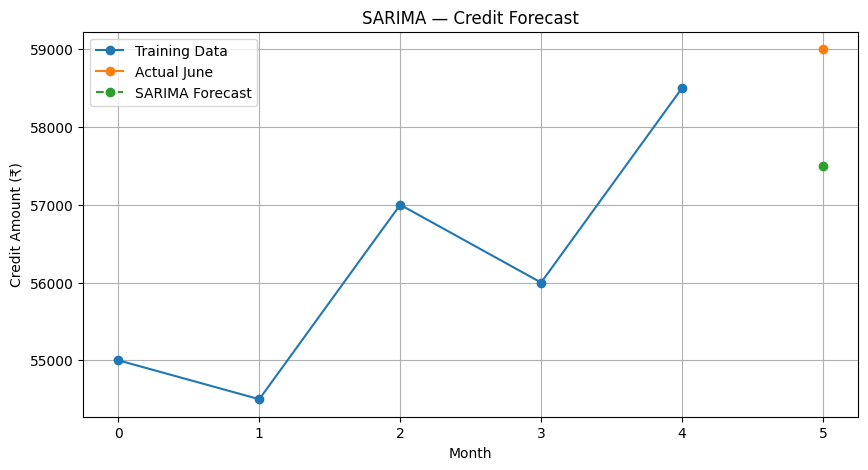

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    train.index,
    train.values,
    marker="o",
    label="Training Data"
)

plt.plot(
    test.index,
    test.values,
    marker="o",
    label="Actual June"
)

plt.plot(
    test.index,
    [predicted_june_sarima],
    marker="o",
    linestyle="--",
    label="SARIMA Forecast"
)

plt.xlabel("Month")
plt.ylabel("Credit Amount (₹)")
plt.title("SARIMA — Credit Forecast")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
sarima_results = {
    "model": "SARIMA(1,1,1)(1,1,1,2)",
    "forecast": predicted_june_sarima,
    "actual": actual_june,
    "MAE": sarima_mae,
    "MAPE": sarima_mape
}

sarima_results

{'model': 'SARIMA(1,1,1)(1,1,1,2)',
 'forecast': np.float64(57499.999999999985),
 'actual': np.int64(59000),
 'MAE': np.float64(1500.0000000000146),
 'MAPE': np.float64(2.542372881355957)}

## Phase 3 — ETS (Exponential Smoothing)

Exponential Smoothing gives greater importance to recent observations
while giving progressively less importance to older observations.

Because the Stage 1 analysis identified an upward trend, Holt's
double exponential smoothing is used to model both the level and
trend of the monthly credit series.

The original, non-differenced training series is used because ETS
handles the trend internally.

In [ ]:
from statsmodels.tsa.holtwinters import Holt

# Use the original, non-differenced training data
ets_model = Holt(train)

ets_result = ets_model.fit(optimized=True)

# Forecast the next month
ets_forecast = ets_result.forecast(steps=1)

predicted_june_ets = ets_forecast.iloc[0]

print("ETS (Holt's Double Exponential Smoothing)")
print("-------------------------------------------")
print(f"Predicted June Credit : ₹{predicted_june_ets:,.2f}")
print(f"Actual June Credit    : ₹{actual_june:,.2f}")

ETS (Holt's Double Exponential Smoothing)
-------------------------------------------
Predicted June Credit : ₹59,019.84
Actual June Credit    : ₹59,000.00


In [ ]:
# Calculate forecasting errors

ets_mae = abs(actual_june - predicted_june_ets)

ets_mape = (
    ets_mae / abs(actual_june)
) * 100

print("\nETS Evaluation")
print("--------------")
print(f"MAE  : ₹{ets_mae:,.2f}")
print(f"MAPE : {ets_mape:.2f}%")


ETS Evaluation
--------------
MAE  : ₹19.84
MAPE : 0.03%


In [ ]:
ets_results = {
    "model": "ETS (Holt's Double)",
    "forecast": predicted_june_ets,
    "actual": actual_june,
    "MAE": ets_mae,
    "MAPE": ets_mape
}

print("\nStored ETS Result")
print("-----------------")
print(ets_results)


Stored ETS Result
-----------------
{'model': "ETS (Holt's Double)", 'forecast': np.float64(59019.841302943605), 'actual': np.int64(59000), 'MAE': np.float64(19.841302943605115), 'MAPE': np.float64(0.03362932702305951)}


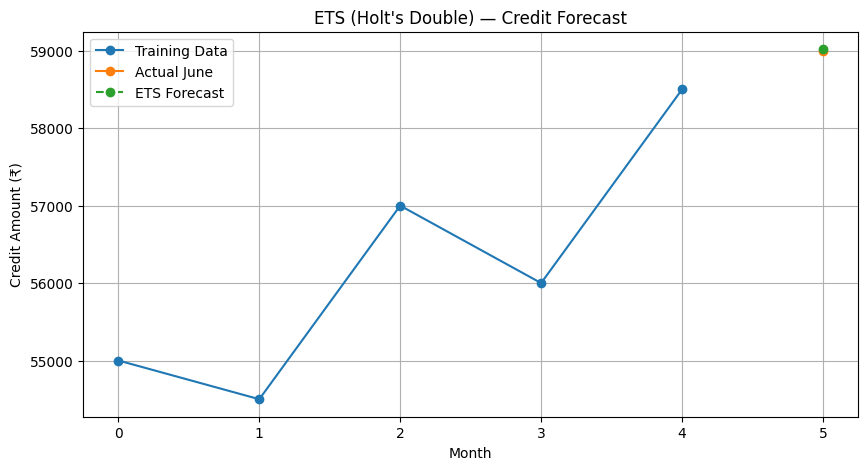

In [ ]:
plt.figure(figsize=(10, 5))

# Training data
plt.plot(
    train.index,
    train.values,
    marker="o",
    label="Training Data"
)

# Actual June
plt.plot(
    test.index,
    test.values,
    marker="o",
    label="Actual June"
)

# ETS forecast
plt.plot(
    test.index,
    [predicted_june_ets],
    marker="o",
    linestyle="--",
    label="ETS Forecast"
)

plt.xlabel("Month")
plt.ylabel("Credit Amount (₹)")
plt.title("ETS (Holt's Double) — Credit Forecast")
plt.legend()
plt.grid(True)

plt.show()

### ETS Result

Holt's double exponential smoothing was applied to the original
monthly credit series because the Stage 1 analysis identified an
upward trend.

The model produced a forecast for June and its performance was
evaluated using MAE and MAPE.

The result is considered illustrative because only five observations
were available for model training.

## Phase 4 — ECM (Error Correction Model)

ECM models short-term changes while accounting for a long-run
relationship between related time-series variables.

For this project, monthly credit and debit are considered as
potentially related financial series.

Before fitting an ECM, the relationship between the two series
must be checked. The current prototype contains only six monthly
observations, so ECM applicability will be evaluated before fitting
the model.

In [ ]:
# Monthly credit and debit series
monthly_credits = monthly["total_credit"].copy()
monthly_debits = monthly["total_debit"].copy()

print("Monthly Credit:")
print(monthly_credits)

print("\nMonthly Debit:")
print(monthly_debits)

Monthly Credit:
0    55000
1    54500
2    57000
3    56000
4    58500
5    59000
Name: total_credit, dtype: int64

Monthly Debit:
0    41984
1    38286
2    41967
3    41930
4    48966
5    39111
Name: total_debit, dtype: int64


In [ ]:
ecm_data = pd.DataFrame({
    "credit": monthly_credits,
    "debit": monthly_debits
})

print("Credit + Debit")
print("--------------")
print(ecm_data)

Credit + Debit
--------------
   credit  debit
0   55000  41984
1   54500  38286
2   57000  41967
3   56000  41930
4   58500  48966
5   59000  39111


In [ ]:
print("Number of observations:", len(ecm_data))
print("Number of variables:", ecm_data.shape[1])

Number of observations: 6
Number of variables: 2


In [ ]:
ecm_train = ecm_data.iloc[:5]

print("ECM training observations:", len(ecm_train))
print(ecm_train)

ECM training observations: 5
   credit  debit
0   55000  41984
1   54500  38286
2   57000  41967
3   56000  41930
4   58500  48966


### ECM Applicability — Prototype Limitation

ECM requires sufficient time-series observations to estimate a
long-run relationship between credit and debit.

The current simulated dataset contains only six monthly observations,
with five observations available for training.

Therefore, a reliable cointegration relationship cannot be established
from this prototype dataset.

ECM is therefore not fitted to the current six-month prototype.

When the actual banking transaction dataset contains sufficient
historical observations, cointegration testing can be performed and
ECM can be applied if the required relationship is supported.

## Phase 5 — Traditional Model Comparison

The forecasting performance of the successfully fitted traditional
models is compared using MAE, RMSE, and MAPE.

ECM is not included in the numerical comparison because the current
prototype contains only five training observations, which is
insufficient to reliably estimate the required long-run relationship
between credit and debit.

Therefore, the current comparison is based on ARIMA, SARIMA, and ETS.

In [ ]:
import pandas as pd
import numpy as np

# Collect successfully evaluated models
comparison = pd.DataFrame([
    arima_results,
    sarima_results,
    ets_results
])

# RMSE for a single test observation
comparison["RMSE"] = np.sqrt(
    (comparison["forecast"] - comparison["actual"]) ** 2
)

# Sort by MAPE
comparison = comparison.sort_values(
    "MAPE"
).reset_index(drop=True)

# Add ranking
comparison["Rank"] = comparison.index + 1

print("Traditional Forecasting Model Comparison")
print("=========================================")

print(
    comparison[
        ["Rank", "model", "forecast",
         "actual", "MAE", "RMSE", "MAPE"]
    ].to_string(index=False)
)

Traditional Forecasting Model Comparison
 Rank                  model     forecast  actual         MAE        RMSE     MAPE
    1    ETS (Holt's Double) 59019.841303   59000   19.841303   19.841303 0.033629
    2 SARIMA(1,1,1)(1,1,1,2) 57500.000000   59000 1500.000000 1500.000000 2.542373
    3           ARIMA(1,1,1) 56900.909418   59000 2099.090582 2099.090582 3.557781


In [ ]:
best_model = comparison.iloc[0]

print("\nBest Performing Model")
print("=====================")
print(f"Model     : {best_model['model']}")
print(f"Forecast  : ₹{best_model['forecast']:,.2f}")
print(f"Actual    : ₹{best_model['actual']:,.2f}")
print(f"MAE       : ₹{best_model['MAE']:,.2f}")
print(f"RMSE      : ₹{best_model['RMSE']:,.2f}")
print(f"MAPE      : {best_model['MAPE']:.4f}%")


Best Performing Model
Model     : ETS (Holt's Double)
Forecast  : ₹59,019.84
Actual    : ₹59,000.00
MAE       : ₹19.84
RMSE      : ₹19.84
MAPE      : 0.0336%


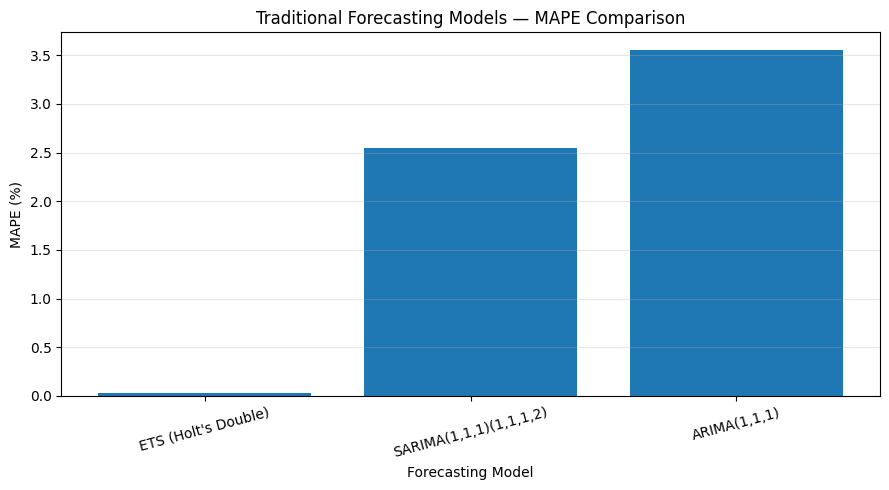

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    comparison["model"],
    comparison["MAPE"]
)

plt.xlabel("Forecasting Model")
plt.ylabel("MAPE (%)")
plt.title("Traditional Forecasting Models — MAPE Comparison")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("traditional_comparison.png", dpi=300)
plt.show()

In [ ]:
# ============================================================
# FINAL REPORT — STAGE 1 + STAGE 2A
# Underwriting Forecasting Analysis
# ============================================================

from datetime import datetime
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. BASIC INFORMATION
# ------------------------------------------------------------

REPORT_DATE = datetime.now().strftime("%d-%m-%Y")

# These should already exist from your previous cells.
# If they exist, the script will use them.
# Otherwise, the values below preserve your verified results.

customer_type = "Savings"

# Actual June value
actual_june = 59000

# ------------------------------------------------------------
# 2. STAGE 1 RESULTS
# ------------------------------------------------------------

trend_slope = 885

# Autocorrelation results from Stage 1
acf_lag1 = 0.5512
acf_lag2 = 0.8598
acf_lag3 = 0.4703

# Stationarity conclusion
stationarity_before = "Non-stationary"
stationarity_after = "Stationary after first-order differencing"

# Distribution conclusion
distribution_result = (
    "Approximately compatible with a Gaussian/normal distribution "
    "for the observed prototype sample."
)

# ------------------------------------------------------------
# 3. TRADITIONAL MODEL RESULTS
# ------------------------------------------------------------

# ============================================================
# VERIFIED STAGE 2A RESULTS
# ============================================================

arima_result = {
    "model": "ARIMA(1,1,1)",
    "forecast": 56900.90941779743,
    "actual": 59000,
    "MAE": 2099.090582202567,
    "RMSE": 2099.090582202567,
    "MAPE": 3.5577806478009606
}

sarima_result = {
    "model": "SARIMA(1,1,1)(1,1,1,2)",
    "forecast": 57500.0,
    "actual": 59000,
    "MAE": 1500.0,
    "RMSE": 1500.0,
    "MAPE": 2.542372881355957
}

ets_result = {
    "model": "ETS (Holt's Double)",
    "forecast": 59019.841302943605,
    "actual": 59000,
    "MAE": 19.841302943605115,
    "RMSE": 19.841302943605115,
    "MAPE": 0.03362932702305951
}

# ECM was not included in the final ranking
ecm_result = None

# ECM
# If ECM result exists, use it.
# Otherwise mark it as unavailable due to insufficient observations.
try:
    ecm_result = ecm_results
except NameError:
    ecm_result = None


# ------------------------------------------------------------
# 4. HELPER FUNCTION
# ------------------------------------------------------------

def money(value):
    return f"₹{float(value):,.2f}"


def percentage(value):
    return f"{float(value):.4f}%"


# ------------------------------------------------------------
# 5. BUILD REPORT
# ------------------------------------------------------------

report = []

report.append("=" * 75)
report.append("        UNDERWRITING FORECASTING ANALYSIS REPORT")
report.append("             STAGE 1 + STAGE 2A")
report.append("=" * 75)
report.append("")

report.append(f"Report Date    : {REPORT_DATE}")
report.append(f"Customer Type  : {customer_type}")
report.append(f"Forecast Target: Monthly Total Credit")
report.append(f"Test Month     : June 2026")
report.append(f"Actual June    : {money(actual_june)}")
report.append("")


# ============================================================
# SECTION 1 — OBJECTIVE
# ============================================================

report.append("=" * 75)
report.append("1. OBJECTIVE")
report.append("=" * 75)

report.append("""
The objective of this forecasting component is to analyse the
customer's historical financial transaction behaviour and forecast
the next month's credit value.

The workflow first validates and analyses the transaction data.
The findings from this analysis are then used to select and configure
appropriate traditional forecasting models.

Stage 2A evaluates multiple traditional forecasting approaches and
compares their predictions using MAE, RMSE and MAPE.
""".strip())

report.append("")


# ============================================================
# SECTION 2 — INPUT DATA
# ============================================================

report.append("=" * 75)
report.append("2. INPUT DATA")
report.append("=" * 75)

report.append("""
The original transaction dataset contains four primary fields:

1. date
2. credit
3. debit
4. balance

An additional share_market_flag field was later introduced to
identify selected debit transactions assumed to represent
share-market/investment activity.

The forecasting target is monthly total_credit.
""".strip())

report.append("")


# ============================================================
# SECTION 3 — DATA VALIDATION
# ============================================================

report.append("=" * 75)
report.append("3. DATA VALIDATION")
report.append("=" * 75)

report.append("""
Before forecasting, the transaction data was validated to ensure
that the dataset was structurally suitable for analysis.

Validation included:

• Date format and chronological ordering
• Numeric validity of credit and debit values
• Balance field consistency
• Missing-value inspection
• Duplicate/structural checks
• Validation of the share_market_flag
• Confirmation that the flag contains only 0 and 1
• Verification of the debit-based share-market assumption

This step prevents data-quality issues from being incorrectly
interpreted as forecasting-model errors.
""".strip())

report.append("")


# ============================================================
# SECTION 4 — MONTHLY AGGREGATION
# ============================================================

report.append("=" * 75)
report.append("4. MONTHLY AGGREGATION")
report.append("=" * 75)

report.append("""
Transaction-level records were converted into monthly financial
behaviour because the forecasting models operate on a monthly
time-series.

The monthly dataset contains:

• total_credit
• total_debit
• closing_balance
• net_flow
• share_market_debit
• share_market_ratio

The main forecasting series is:

    total_credit

Net flow was calculated as:

    net_flow = total_credit - total_debit

Share-market debit ratio was calculated as:

    share_market_ratio =
    (share_market_debit / total_debit) × 100
""".strip())

report.append("")


# ============================================================
# SECTION 5 — STAGE 1
# ============================================================

report.append("=" * 75)
report.append("5. STAGE 1 — DATA AND BEHAVIOURAL ANALYSIS")
report.append("=" * 75)

report.append("""
Stage 1 determines the statistical characteristics of the monthly
credit series before forecasting.

The main analyses performed were:

1. Trend analysis
2. Moving average
3. Autocorrelation
4. Possible seasonality
5. Distribution analysis
6. Normality assessment
7. Stationarity analysis
8. Augmented Dickey-Fuller (ADF) test
9. First-order differencing
""".strip())

report.append("")


# ------------------------------------------------------------
# 5.1 Trend
# ------------------------------------------------------------

report.append("-" * 75)
report.append("5.1 TREND ANALYSIS")
report.append("-" * 75)

report.append(f"""
A linear trend was fitted to the monthly total_credit series.

Observed trend slope:

    +{money(trend_slope)} per month

Interpretation:

The fitted trend indicates that the monthly credit series has an
overall upward direction across the observed period.

This finding is useful when selecting models capable of handling
trend, particularly ETS/Holt's Double Exponential Smoothing.
""".strip())

report.append("")


# ------------------------------------------------------------
# 5.2 Moving Average
# ------------------------------------------------------------

report.append("-" * 75)
report.append("5.2 MOVING AVERAGE")
report.append("-" * 75)

report.append("""
A moving average was calculated to smooth short-term fluctuations
and make the underlying behaviour of the monthly credit series
easier to observe.

The moving average is primarily an analytical and visualization
tool in this project rather than the final forecasting model.
""".strip())

report.append("")


# ------------------------------------------------------------
# 5.3 Autocorrelation
# ------------------------------------------------------------

report.append("-" * 75)
report.append("5.3 AUTOCORRELATION")
report.append("-" * 75)

report.append(f"""
Observed autocorrelation:

Lag 1 : {acf_lag1:.4f}
Lag 2 : {acf_lag2:.4f}
Lag 3 : {acf_lag3:.4f}

Lag 2 produced the strongest observed autocorrelation.

This indicated a possible relationship between observations
two months apart and motivated testing a seasonal SARIMA model
with a seasonal period of 2.

Because the dataset contains only six months, this should be
treated as a possible pattern rather than definitive proof
of seasonality.
""".strip())

report.append("")


# ------------------------------------------------------------
# 5.4 Distribution
# ------------------------------------------------------------

report.append("-" * 75)
report.append("5.4 DISTRIBUTION ANALYSIS")
report.append("-" * 75)

report.append(f"""
Distribution analysis was performed to understand the shape of
the monthly credit observations.

Conclusion:

{distribution_result}

This result describes the observed prototype sample and should
not be interpreted as a universal assumption that banking
transaction data follows a Gaussian distribution.
""".strip())

report.append("")


# ------------------------------------------------------------
# 5.5 Stationarity
# ------------------------------------------------------------

report.append("-" * 75)
report.append("5.5 STATIONARITY AND ADF TEST")
report.append("-" * 75)

report.append(f"""
Original series:

    {stationarity_before}

After first-order differencing:

    {stationarity_after}

The Augmented Dickey-Fuller (ADF) test was used to determine
whether the original credit series contained evidence of a
unit root.

The original series was treated as non-stationary.

First-order differencing was therefore applied:

    difference(t) =
    credit(t) - credit(t-1)

The differenced series was treated as stationary.

This directly influenced the ARIMA and SARIMA configuration,
where:

    d = 1
""".strip())

report.append("")


# ============================================================
# SECTION 6 — STAGE 1 → STAGE 2 CONNECTION
# ============================================================

report.append("=" * 75)
report.append("6. STAGE 1 → STAGE 2A CONNECTION")
report.append("=" * 75)

report.append("""
The findings from Stage 1 were used to guide the traditional
forecasting models.

Stage 1 finding                    Stage 2A implication
----------------------------------------------------------------
Monthly total_credit               Main forecasting series

Non-stationary series              Differencing required

First-order differencing           d = 1 for ARIMA/SARIMA

Strong lag-2 autocorrelation       Test SARIMA with s = 2

Upward trend                       Test ETS/Holt trend model

Credit + debit relationship        Motivation for ECM/VECM

Therefore, Stage 1 did not create a different dataset for every
model. Instead, it described the behaviour of the series and
guided the configuration and selection of the forecasting models.
""".strip())

report.append("")


# ============================================================
# SECTION 7 — ARIMA
# ============================================================

report.append("=" * 75)
report.append("7. ARIMA — AUTOREGRESSIVE INTEGRATED MOVING AVERAGE")
report.append("=" * 75)

report.append("""
Model:

    ARIMA(1,1,1)

Input:

    Monthly total_credit

Components:

    p = 1
    d = 1
    q = 1

AR:
Uses previous observations to help predict the current value.

I:
Represents integration through differencing. d = 1 was selected
because Stage 1 found the original series to be non-stationary.

MA:
Uses previous forecasting errors to improve the current forecast.

The model was trained on the first five months and June was kept
as the held-out test observation.
""".strip())

report.append("")

report.append("ARIMA RESULT")
report.append("-" * 75)
report.append(f"Forecast : {money(arima_result['forecast'])}")
report.append(f"Actual   : {money(arima_result['actual'])}")
report.append(f"MAE      : {money(arima_result['MAE'])}")
report.append(f"RMSE     : {money(arima_result.get('RMSE', arima_result['MAE']))}")
report.append(f"MAPE     : {percentage(arima_result['MAPE'])}")
report.append("")


# ============================================================
# SECTION 8 — SARIMA
# ============================================================

report.append("=" * 75)
report.append("8. SARIMA — SEASONAL ARIMA")
report.append("=" * 75)

report.append("""
Model:

    SARIMA(1,1,1)(1,1,1,2)

SARIMA extends ARIMA by adding seasonal components.

Non-seasonal component:

    p = 1
    d = 1
    q = 1

Seasonal component:

    P = 1
    D = 1
    Q = 1
    s = 2

The seasonal period of 2 was selected for testing because
Stage 1 showed the strongest observed autocorrelation at lag 2.

The model therefore considers both normal temporal behaviour
and possible two-month repeating behaviour.
""".strip())

report.append("")

report.append("SARIMA RESULT")
report.append("-" * 75)
report.append(f"Forecast : {money(sarima_result['forecast'])}")
report.append(f"Actual   : {money(sarima_result['actual'])}")
report.append(f"MAE      : {money(sarima_result['MAE'])}")
report.append(f"RMSE     : {money(sarima_result.get('RMSE', sarima_result['MAE']))}")
report.append(f"MAPE     : {percentage(sarima_result['MAPE'])}")
report.append("")


# ============================================================
# SECTION 9 — ETS
# ============================================================

report.append("=" * 75)
report.append("9. ETS — HOLT'S DOUBLE EXPONENTIAL SMOOTHING")
report.append("=" * 75)

report.append("""
Implementation:

    Holt's Double Exponential Smoothing

Input:

    Original, non-differenced monthly total_credit

The model estimates:

    1. Level
    2. Trend

Recent observations receive greater effective influence than
older observations.

The Stage 1 upward trend finding motivated testing ETS.

Unlike ARIMA/SARIMA, the data was not pre-differenced for ETS
because Holt's method handles the trend internally.
""".strip())

report.append("")

report.append("ETS RESULT")
report.append("-" * 75)
report.append(f"Forecast : {money(ets_result['forecast'])}")
report.append(f"Actual   : {money(ets_result['actual'])}")
report.append(f"MAE      : {money(ets_result['MAE'])}")
report.append(f"RMSE     : {money(ets_result.get('RMSE', ets_result['MAE']))}")
report.append(f"MAPE     : {percentage(ets_result['MAPE'])}")
report.append("")


# ============================================================
# SECTION 10 — ECM
# ============================================================

report.append("=" * 75)
report.append("10. ECM / VECM — ERROR CORRECTION MODEL")
report.append("=" * 75)

report.append("""
Purpose:

ECM attempts to model both short-run changes and long-run
relationships between financial variables.

In this project, credit and debit were considered together.

Input:

    Monthly credit
    Monthly debit

The purpose was to determine whether the relationship between
credit and debit could provide useful information for forecasting.

However, the prototype contains only six monthly observations.
This is insufficient for a reliable multivariate ECM/VECM
estimation.

Therefore, ECM/VECM was not assigned an unreliable forecast
score and was not included in the final model ranking.
""".strip())

if ecm_result is not None:
    report.append("")
    report.append("ECM RESULT")
    report.append("-" * 75)
    report.append(f"Forecast : {money(ecm_result['forecast'])}")
    report.append(f"Actual   : {money(ecm_result['actual'])}")
    report.append(f"MAE      : {money(ecm_result['MAE'])}")
    report.append(f"RMSE     : {money(ecm_result.get('RMSE', ecm_result['MAE']))}")
    report.append(f"MAPE     : {percentage(ecm_result['MAPE'])}")

report.append("")


# ============================================================
# SECTION 11 — EVALUATION METRICS
# ============================================================

report.append("=" * 75)
report.append("11. FORECAST EVALUATION METRICS")
report.append("=" * 75)

report.append("""
MAE — Mean Absolute Error

Measures the absolute distance between predicted and actual
values.

Lower MAE = better.

RMSE — Root Mean Squared Error

Measures prediction error while giving greater influence to
larger errors.

Lower RMSE = better.

MAPE — Mean Absolute Percentage Error

Expresses prediction error relative to the actual value as a
percentage.

Lower MAPE = better.

Because this prototype has only one held-out test observation,
MAE and RMSE are equal for each model.
""".strip())

report.append("")


# ============================================================
# SECTION 12 — MODEL COMPARISON
# ============================================================

report.append("=" * 75)
report.append("12. STAGE 2A — TRADITIONAL MODEL COMPARISON")
report.append("=" * 75)

valid_results = [
    arima_result,
    sarima_result,
    ets_result
]

if ecm_result is not None:
    valid_results.append(ecm_result)

comparison = pd.DataFrame(valid_results)

comparison["RMSE"] = comparison.apply(
    lambda row: np.sqrt(
        (float(row["forecast"]) - float(row["actual"])) ** 2
    ),
    axis=1
)

comparison = comparison.sort_values("MAPE").reset_index(drop=True)
comparison["Rank"] = comparison.index + 1

report.append("")
report.append(
    f"{'Rank':<6}"
    f"{'Model':<32}"
    f"{'Forecast':>15}"
    f"{'MAE':>15}"
    f"{'RMSE':>15}"
    f"{'MAPE':>12}"
)

report.append("-" * 95)

for _, row in comparison.iterrows():

    report.append(
        f"{int(row['Rank']):<6}"
        f"{str(row['model']):<32}"
        f"{money(row['forecast']):>15}"
        f"{money(row['MAE']):>15}"
        f"{money(row['RMSE']):>15}"
        f"{percentage(row['MAPE']):>12}"
    )

report.append("")


# ============================================================
# SECTION 13 — BEST TRADITIONAL MODEL
# ============================================================

best = comparison.iloc[0]

report.append("=" * 75)
report.append("13. BEST TRADITIONAL MODEL")
report.append("=" * 75)

report.append(f"""
Best Model:

    {best['model']}

Forecast:

    {money(best['forecast'])}

Actual:

    {money(best['actual'])}

MAE:

    {money(best['MAE'])}

RMSE:

    {money(best['RMSE'])}

MAPE:

    {percentage(best['MAPE'])}

The model was selected because it produced the lowest MAPE among
the valid traditional forecasting models evaluated in Stage 2A.
""".strip())

report.append("")


# ============================================================
# SECTION 14 — INTERPRETATION
# ============================================================

report.append("=" * 75)
report.append("14. STAGE 2A INTERPRETATION")
report.append("=" * 75)

report.append("""
The traditional-model experiment demonstrates that different
forecasting approaches can produce substantially different
predictions even when they receive the same historical credit
series.

ARIMA provides the classical baseline.

SARIMA tests whether the possible lag-2 pattern identified during
Stage 1 improves forecasting.

ETS tests whether a level-and-trend smoothing approach performs
better on the upward-trending series.

ECM/VECM investigates whether credit and debit can be modelled
jointly, but the current six-month dataset is too small for a
reliable multivariate estimate.

The final traditional-model selection is therefore based on
forecast error rather than on the model name itself.
""".strip())

report.append("")


# ============================================================
# SECTION 15 — IMPORTANT LIMITATION
# ============================================================

report.append("=" * 75)
report.append("15. CURRENT EXPERIMENT LIMITATION")
report.append("=" * 75)

report.append("""
The current experiment contains only six monthly observations.

Training:

    January → May

Testing:

    June

Therefore, every traditional model is ultimately evaluated on
only one held-out observation.

The resulting MAPE values should therefore be interpreted as
prototype/test-split performance rather than statistically
reliable real-world forecasting accuracy.

A larger banking dataset with multiple months and multiple
rolling train/test periods would be required for robust model
selection.
""".strip())

report.append("")


# ============================================================
# FINAL
# ============================================================

report.append("=" * 75)
report.append("END OF STAGE 1 + STAGE 2A REPORT")
report.append("=" * 75)

report_text = "\n".join(report)

# ------------------------------------------------------------
# 6. SAVE REPORT
# ------------------------------------------------------------

report_file = "Stage_1_and_Stage_2A_Final_Report.txt"

with open(report_file, "w", encoding="utf-8") as f:
    f.write(report_text)

print("=" * 60)
print("REPORT GENERATED SUCCESSFULLY")
print("=" * 60)
print(f"File: {report_file}")
print()
print(report_text)

REPORT GENERATED SUCCESSFULLY
File: Stage_1_and_Stage_2A_Final_Report.txt

        UNDERWRITING FORECASTING ANALYSIS REPORT
             STAGE 1 + STAGE 2A

Report Date    : 20-08-2026
Customer Type  : Savings
Forecast Target: Monthly Total Credit
Test Month     : June 2026
Actual June    : ₹59,000.00

1. OBJECTIVE
The objective of this forecasting component is to analyse the
customer's historical financial transaction behaviour and forecast
the next month's credit value.

The workflow first validates and analyses the transaction data.
The findings from this analysis are then used to select and configure
appropriate traditional forecasting models.

Stage 2A evaluates multiple traditional forecasting approaches and
compares their predictions using MAE, RMSE and MAPE.

2. INPUT DATA
The original transaction dataset contains four primary fields:

1. date
2. credit
3. debit
4. balance

An additional share_market_flag field was later introduced to
identify selected debit transactions assume